# K-Moda MMM — Fase 1: ETL y Auditoría de Datos

**Objetivo:** Construir la señal de ventas limpia, validar la calidad de todos los datasets y exportar los artefactos intermedios para las fases posteriores.

**Outputs:**
- `data/df_ventas_clean.parquet` — ventas netas semanales nacionales (Y_t)
- `data/df_inversion_clean.parquet` — inversión semanal nacional por canal (X_t,m)

---
**Reglas críticas aplicadas en esta fase:**
1. Variable dependiente: siempre `venta_neta_sin_iva_eur` de ventas_lineas. Nunca el bruto de pedidos.
2. LEFT JOIN obligatorio: la tabla raíz es CALENDARIO. Los días/semanas sin ventas → 0, no eliminados.
3. Granularidad final: semanal nacional (suma de todas las ciudades disponibles).

## 0. Configuración e Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Rutas ────────────────────────────────────────────────────────────────────
ROOT     = Path('.')
DATA_RAW = ROOT          # CSVs originales en la raíz
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
DATA_OUT.mkdir(exist_ok=True)
IMG_DIR.mkdir(exist_ok=True)

# ── Paleta K-Moda ─────────────────────────────────────────────────────────────
KM = {
    'gold':        '#C9A84C',
    'gold_light':  '#E8D5A3',
    'charcoal':    '#2C2C2C',
    'warm_gray':   '#6B6560',
    'off_white':   '#F7F5F0',
    'white':       '#FFFFFF',
    'paid_search': '#1A6B8A',
    'social_paid': '#E07B39',
    'video':       '#8B5E9E',
    'display':     '#3A9E6F',
    'email_crm':   '#D4A843',
    'radio':       '#C0504D',
    'exterior':    '#4F7CAC',
    'prensa':      '#7A7A52',
    'positive':    '#2E7D52',
    'neutral':     '#C9A84C',
    'negative':    '#B33A3A',
    'base':        '#D6CFC4',
}

CANAL_COLOR = {
    'Paid Search': KM['paid_search'],
    'Social Paid': KM['social_paid'],
    'Video Online': KM['video'],
    'Display':     KM['display'],
    'Email CRM':   KM['email_crm'],
    'Radio Local': KM['radio'],
    'Exterior':    KM['exterior'],
    'Prensa':      KM['prensa'],
}

# ── Estilo global matplotlib ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  KM['off_white'],
    'axes.facecolor':    KM['off_white'],
    'axes.edgecolor':    KM['warm_gray'],
    'axes.labelcolor':   KM['charcoal'],
    'xtick.color':       KM['charcoal'],
    'ytick.color':       KM['charcoal'],
    'text.color':        KM['charcoal'],
    'grid.color':        KM['gold_light'],
    'grid.alpha':        0.5,
    'axes.grid':         True,
    'font.family':       'sans-serif',
    'font.size':         11,
})

def save_fig(name: str, fig=None):
    f = fig or plt.gcf()
    path = IMG_DIR / f'{name}.png'
    f.savefig(path, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {path}')

print('Configuracion K-Moda cargada.')

Configuracion K-Moda cargada.


## 1. Carga de datos

In [4]:
print('Cargando datasets...')

df_ventas = pd.read_csv(
    DATA_RAW / 'ventas_lineas.csv',
    parse_dates=['fecha_venta'],
    dtype={'descuento_pct': 'int8'},
)

df_pedidos = pd.read_csv(
    DATA_RAW / 'pedidos.csv',
    parse_dates=['fecha_pedido'],
)

df_cal = pd.read_csv(
    DATA_RAW / 'calendario_ciudad.csv',
    parse_dates=['fecha'],
)

df_inv = pd.read_csv(
    DATA_RAW / 'inversion_medios_semanal.csv',
    parse_dates=['semana_inicio', 'semana_fin'],
)

df_trafico = pd.read_csv(
    DATA_RAW / 'trafico_tienda_web_diario.csv',
    parse_dates=['fecha'],
)

df_clientes = pd.read_csv(DATA_RAW / 'clientes.csv')
df_productos = pd.read_csv(DATA_RAW / 'productos.csv')

datasets = {
    'ventas_lineas':    df_ventas,
    'pedidos':          df_pedidos,
    'calendario':       df_cal,
    'inversion_medios': df_inv,
    'trafico':          df_trafico,
    'clientes':         df_clientes,
    'productos':        df_productos,
}

for name, df in datasets.items():
    print(f'  {name:20s}: {df.shape[0]:>9,} filas × {df.shape[1]} cols')

print('\nCarga completada.')

Cargando datasets...
  ventas_lineas       : 8,000,000 filas × 15 cols
  pedidos             : 8,000,000 filas × 9 cols
  calendario          :    18,270 filas × 18 cols
  inversion_medios    :    20,880 filas × 9 cols
  trafico             :    18,270 filas × 18 cols
  clientes            :   600,000 filas × 9 cols
  productos           :       510 filas × 9 cols

Carga completada.


## 2. Auditoría de calidad de datos

In [5]:
print('=' * 65)
print('AUDITORIA DE NULOS Y RANGOS TEMPORALES')
print('=' * 65)

for name, df in datasets.items():
    nulos = df.isna().sum()
    nulos_total = nulos.sum()
    fecha_cols = [c for c in df.columns
                  if ('fecha' in c or 'semana_inicio' in c)
                  and pd.api.types.is_datetime64_any_dtype(df[c])]
    rango = ''
    if fecha_cols:
        col = fecha_cols[0]
        rango = f'  Rango {col}: {df[col].min().date()} -> {df[col].max().date()}'
    print(f'\n-- {name} --')
    print(f'  Nulos totales: {nulos_total}')
    if nulos_total > 0:
        print(nulos[nulos > 0].to_string())
    print(rango)

AUDITORIA DE NULOS Y RANGOS TEMPORALES

-- ventas_lineas --
  Nulos totales: 0
  Rango fecha_venta: 2020-01-01 -> 2024-12-31

-- pedidos --
  Nulos totales: 0
  Rango fecha_pedido: 2020-01-01 -> 2024-12-31

-- calendario --
  Nulos totales: 0
  Rango fecha: 2020-01-01 -> 2024-12-31

-- inversion_medios --
  Nulos totales: 0
  Rango semana_inicio: 2020-01-06 -> 2024-12-30

-- trafico --
  Nulos totales: 0
  Rango fecha: 2020-01-01 -> 2024-12-31

-- clientes --
  Nulos totales: 0


-- productos --
  Nulos totales: 0



In [6]:
# Verificar tipos de datos críticos
print('VERIFICACIÓN DE TIPOS — COLUMNAS CLAVE')
print('-' * 45)
checks = [
    ('ventas_lineas',    'venta_neta_sin_iva_eur', df_ventas),
    ('ventas_lineas',    'pvp_bruto_eur',          df_ventas),
    ('inversion_medios', 'inversion_eur',           df_inv),
    ('inversion_medios', 'semana_inicio',           df_inv),
    ('calendario',       'fecha',                   df_cal),
]
for tabla, col, df in checks:
    negatives = (df[col] < 0).sum() if df[col].dtype in ['float64', 'int64'] else 'N/A'
    print(f'  {tabla:20s}.{col:28s}: dtype={df[col].dtype}, negativos={negatives}')

# Ventas negativas — devoluciones
n_neg = (df_ventas['venta_neta_sin_iva_eur'] < 0).sum()
print(f'\n  Ventas con venta_neta < 0 (devoluciones): {n_neg:,}')
print(f'  % sobre total líneas: {n_neg / len(df_ventas) * 100:.2f}%')
if n_neg > 0:
    val_neg = df_ventas.loc[df_ventas['venta_neta_sin_iva_eur'] < 0, 'venta_neta_sin_iva_eur'].sum()
    print(f'  Importe total devoluciones: {val_neg:,.0f} EUR')

VERIFICACIÓN DE TIPOS — COLUMNAS CLAVE
---------------------------------------------
  ventas_lineas       .venta_neta_sin_iva_eur      : dtype=float64, negativos=0
  ventas_lineas       .pvp_bruto_eur               : dtype=float64, negativos=0
  inversion_medios    .inversion_eur               : dtype=float64, negativos=0
  inversion_medios    .semana_inicio               : dtype=datetime64[ns], negativos=N/A
  calendario          .fecha                       : dtype=datetime64[ns], negativos=N/A

  Ventas con venta_neta < 0 (devoluciones): 0
  % sobre total líneas: 0.00%


## 3. Hallazgo crítico — Mismatch de ciudades

> **Problema:** `ventas_lineas` contiene datos de **5 ciudades**, mientras que `inversion_medios` y `calendario_ciudad` tienen **10 ciudades**. Las 5 ciudades adicionales (A Coruña, Málaga, Murcia, Palma, Zaragoza) tienen inversión publicitaria real (~23.5M EUR, ~39% del total) pero **ningún registro de ventas**.
>
> **Consecuencia para el modelo:** es imposible construir un modelo a nivel ciudad. El modelo operará en **granularidad semanal nacional** (suma de todas las ciudades). La inversión de las 10 ciudades se suma nacionalmente; las ventas de las 5 ciudades también se suman nacionalmente. Este mismatch se documenta y se acepta como limitación del dataset.

In [7]:
ciudades_ventas = set(df_ventas['ciudad'].unique())
ciudades_inv    = set(df_inv['ciudad'].unique())
ciudades_cal    = set(df_cal['ciudad'].unique())

print('AUDITORÍA DE CIUDADES')
print(f'  ventas_lineas ({len(ciudades_ventas)}):  {sorted(ciudades_ventas)}')
print(f'  inversion     ({len(ciudades_inv)}): {sorted(ciudades_inv)}')
print(f'  calendario    ({len(ciudades_cal)}): {sorted(ciudades_cal)}')
print()
print(f'  Ciudades con inversión SIN ventas: {sorted(ciudades_inv - ciudades_ventas)}')
print()

inv_por_ciudad = df_inv.groupby('ciudad')['inversion_eur'].sum().sort_values(ascending=False)
inv_sin_ventas = inv_por_ciudad[inv_por_ciudad.index.isin(ciudades_inv - ciudades_ventas)]
inv_con_ventas = inv_por_ciudad[inv_por_ciudad.index.isin(ciudades_ventas)]
total_inv = inv_por_ciudad.sum()

print(f'  Inversión en ciudades CON ventas:  {inv_con_ventas.sum():>12,.0f} EUR ({inv_con_ventas.sum()/total_inv*100:.1f}%)')
print(f'  Inversión en ciudades SIN ventas:  {inv_sin_ventas.sum():>12,.0f} EUR ({inv_sin_ventas.sum()/total_inv*100:.1f}%)')
print(f'  Total inversión:                   {total_inv:>12,.0f} EUR')

AUDITORÍA DE CIUDADES
  ventas_lineas (5):  ['Barcelona', 'Bilbao', 'Madrid', 'Sevilla', 'Valencia']
  inversion     (10): ['A Coruna', 'Barcelona', 'Bilbao', 'Madrid', 'Malaga', 'Murcia', 'Palma', 'Sevilla', 'Valencia', 'Zaragoza']
  calendario    (10): ['A Coruna', 'Barcelona', 'Bilbao', 'Madrid', 'Malaga', 'Murcia', 'Palma', 'Sevilla', 'Valencia', 'Zaragoza']

  Ciudades con inversión SIN ventas: ['A Coruna', 'Malaga', 'Murcia', 'Palma', 'Zaragoza']

  Inversión en ciudades CON ventas:    36,396,452 EUR (60.7%)
  Inversión en ciudades SIN ventas:    23,603,548 EUR (39.3%)
  Total inversión:                     60,000,000 EUR


  Guardado: img\01a_mismatch_ciudades.png


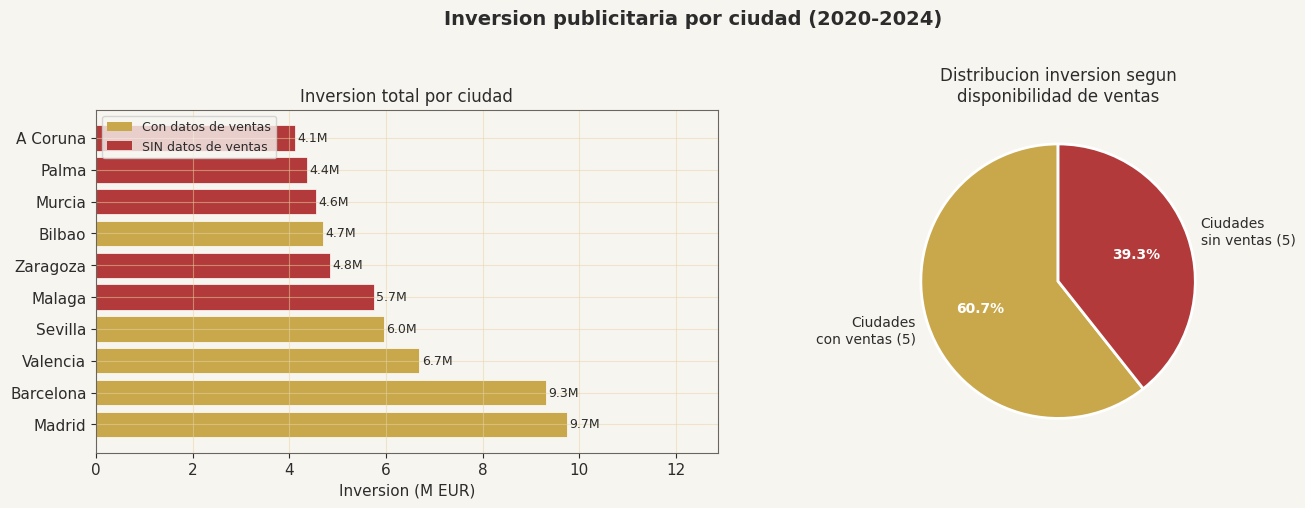

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inversion publicitaria por ciudad (2020-2024)',
             fontsize=14, fontweight='bold', color=KM['charcoal'], y=1.01)

# Grafico 1: inversion por ciudad con indicador de presencia/ausencia de ventas
ax = axes[0]
colors_bar = [KM['negative'] if c in (ciudades_inv - ciudades_ventas) else KM['gold']
              for c in inv_por_ciudad.index]
bars = ax.barh(inv_por_ciudad.index, inv_por_ciudad.values / 1e6,
               color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Inversion (M EUR)', color=KM['charcoal'])
ax.set_title('Inversion total por ciudad', fontsize=12, color=KM['charcoal'])
for bar, val in zip(bars, inv_por_ciudad.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val/1e6:.1f}M', va='center', fontsize=9, color=KM['charcoal'])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=KM['gold'],     label='Con datos de ventas'),
    Patch(facecolor=KM['negative'], label='SIN datos de ventas'),
]
# Leyenda en upper left — no solapa con las etiquetas de las barras (que estan a la derecha)
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_xlim(0, inv_por_ciudad.max() / 1e6 * 1.32)

# Grafico 2: distribucion inversion con/sin ventas
ax2 = axes[1]
labels = ['Ciudades\ncon ventas (5)', 'Ciudades\nsin ventas (5)']
values = [inv_con_ventas.sum() / 1e6, inv_sin_ventas.sum() / 1e6]
wedge_colors = [KM['gold'], KM['negative']]
wedges, texts, autotexts = ax2.pie(
    values, labels=labels, colors=wedge_colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': KM['charcoal'], 'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax2.set_title('Distribucion inversion segun\ndisponibilidad de ventas',
              fontsize=12, color=KM['charcoal'])

plt.tight_layout()
save_fig('01a_mismatch_ciudades')
plt.show()

## 4. Rollup transaccional — Ventas semanales nacionales

In [9]:
# Calcular el lunes de la semana ISO para cada transacción
df_ventas['semana_inicio'] = (
    df_ventas['fecha_venta']
    - pd.to_timedelta(df_ventas['fecha_venta'].dt.dayofweek, unit='D')
)
df_ventas['semana_inicio'] = df_ventas['semana_inicio'].dt.normalize()

# Rollup semanal nacional — suma de todas las ciudades
ventas_weekly = (
    df_ventas
    .groupby('semana_inicio')
    .agg(
        venta_neta_sin_iva_eur=('venta_neta_sin_iva_eur', 'sum'),
        pvp_bruto_eur=('pvp_bruto_eur', 'sum'),
        n_lineas=('id_linea', 'count'),
        n_pedidos=('id_pedido', 'nunique'),
        ticket_medio=('venta_neta_sin_iva_eur', lambda x: x.sum() / x.count()),
    )
    .reset_index()
    .sort_values('semana_inicio')
)

print(f'Semanas en rollup de ventas: {len(ventas_weekly)}')
print(f'Rango: {ventas_weekly.semana_inicio.min().date()} → {ventas_weekly.semana_inicio.max().date()}')
print(f'Ventas totales: {ventas_weekly.venta_neta_sin_iva_eur.sum():,.0f} EUR')
print(f'Media semanal:  {ventas_weekly.venta_neta_sin_iva_eur.mean():,.0f} EUR')
print(f'\nPrimeras 5 filas:')
ventas_weekly.head()

Semanas en rollup de ventas: 262
Rango: 2019-12-30 → 2024-12-30
Ventas totales: 768,090,254 EUR
Media semanal:  2,931,642 EUR

Primeras 5 filas:


,semana_inicio,venta_neta_sin_iva_eur,pvp_bruto_eur,n_lineas,n_pedidos,ticket_medio
0,2019-12-30,1289866.76,1341967.11,13424,13424,96.086618
1,2020-01-06,1744807.79,1818459.26,18287,18287,95.412467
2,2020-01-13,1743767.43,1816110.95,18240,18240,95.601285
3,2020-01-20,1748775.45,1821756.00,18168,18168,96.255804
4,2020-01-27,1771293.40,1845350.35,18397,18397,96.281644


## 5. Columna vertebral semanal desde CALENDARIO

In [10]:
# Calcular lunes de semana para cada día del calendario
df_cal['semana_inicio'] = (
    df_cal['fecha']
    - pd.to_timedelta(df_cal['fecha'].dt.dayofweek, unit='D')
)
df_cal['semana_inicio'] = df_cal['semana_inicio'].dt.normalize()

# Agregación a nivel semanal nacional:
# - Flags binarios: max() — si cualquier día de la semana o ciudad tiene el flag → semana tiene el flag
# - Variables continuas: mean() — promedio nacional de la semana
flag_cols = ['fin_de_semana', 'payday_flag', 'rebajas_flag', 'black_friday_flag',
             'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag',
             'festivo_local_flag', 'incidencia_ecommerce_flag']
cont_cols = ['temperatura_media_c', 'lluvia_indice', 'turismo_indice']

cal_weekly = (
    df_cal
    .groupby('semana_inicio')
    .agg(
        **{col: (col, 'max') for col in flag_cols},
        **{col: (col, 'mean') for col in cont_cols},
        anio=('anio', 'first'),
        mes=('mes', 'first'),
    )
    .reset_index()
    .sort_values('semana_inicio')
)

# Añadir semana ISO y número de semana del año
cal_weekly['semana_iso'] = cal_weekly['semana_inicio'].dt.isocalendar().week.astype(int)
cal_weekly['anio_iso']   = cal_weekly['semana_inicio'].dt.isocalendar().year.astype(int)

print(f'Semanas en spine de calendario: {len(cal_weekly)}')
print(f'Rango: {cal_weekly.semana_inicio.min().date()} → {cal_weekly.semana_inicio.max().date()}')
cal_weekly.head()

Semanas en spine de calendario: 262
Rango: 2019-12-30 → 2024-12-30


,semana_inicio,fin_de_semana,payday_flag,rebajas_flag,black_friday_flag,navidad_flag,semana_santa_flag,vacaciones_escolares_flag,festivo_local_flag,incidencia_ecommerce_flag,temperatura_media_c,lluvia_indice,turismo_indice,anio,mes,semana_iso,anio_iso
0,2019-12-30,1,1,0,0,0,0,0,0,1,8.734000,57.538000,28.220000,2020,1,1,2020
1,2020-01-06,1,0,1,0,0,0,0,0,0,9.957143,59.282857,31.352857,2020,1,2,2020
2,2020-01-13,1,0,1,0,0,0,0,0,0,9.564286,58.067143,29.391429,2020,1,3,2020
3,2020-01-20,1,1,1,0,0,0,0,0,1,10.078571,58.977143,27.392857,2020,1,4,2020
4,2020-01-27,1,1,1,0,0,0,0,0,0,10.471429,60.731429,26.728571,2020,1,5,2020


In [11]:
# LEFT JOIN: calendario como tabla raíz → ventas
# Semanas sin ventas recibirán 0 (no NaN, no eliminadas)
df_ventas_clean = (
    cal_weekly
    .merge(ventas_weekly.drop(columns=['pvp_bruto_eur']), on='semana_inicio', how='left')
)

# Semanas sin ventas → rellenar con 0
cols_fill_zero = ['venta_neta_sin_iva_eur', 'n_lineas', 'n_pedidos', 'ticket_medio']
df_ventas_clean[cols_fill_zero] = df_ventas_clean[cols_fill_zero].fillna(0)

semanas_sin_ventas = (df_ventas_clean['venta_neta_sin_iva_eur'] == 0).sum()
print(f'Total semanas en spine:       {len(df_ventas_clean)}')
print(f'Semanas con ventas > 0:       {(df_ventas_clean.venta_neta_sin_iva_eur > 0).sum()}')
print(f'Semanas sin ventas (= 0):     {semanas_sin_ventas}')
print(f'Total ventas (verificación):  {df_ventas_clean.venta_neta_sin_iva_eur.sum():,.0f} EUR')

assert abs(df_ventas_clean['venta_neta_sin_iva_eur'].sum() - df_ventas['venta_neta_sin_iva_eur'].sum()) < 1, \
    'ERROR: Discrepancia en el total de ventas tras el LEFT JOIN'
print('✓ Integridad verificada: total ventas idéntico antes y después del JOIN')

Total semanas en spine:       262
Semanas con ventas > 0:       262
Semanas sin ventas (= 0):     0
Total ventas (verificación):  768,090,254 EUR
✓ Integridad verificada: total ventas idéntico antes y después del JOIN


## 6. Inversión publicitaria — Agregación semanal nacional

In [12]:
# Semana ISO boundary: la semana que empieza 2024-12-30 tiene anio=2025 en el CSV
# Usamos semana_inicio (datetime) como clave — no el campo anio del CSV
print('Verificación boundary semana ISO fin de 2024:')
print(df_inv[df_inv['semana_inicio'] >= '2024-12-23'][['semana_inicio','semana_fin','anio','semana_iso']]
      .drop_duplicates().to_string(index=False))
print()

# Pivot: semana_inicio × canal_medio → inversion_eur (suma nacional de todas las ciudades)
inv_weekly = (
    df_inv
    .groupby(['semana_inicio', 'canal_medio'])['inversion_eur']
    .sum()
    .unstack('canal_medio')
    .reset_index()
    .sort_values('semana_inicio')
)

# Nombres de columna limpios
inv_weekly.columns.name = None
canales = [c for c in inv_weekly.columns if c != 'semana_inicio']

# Verificar que no hay NaN (todas las semanas deben tener los 8 canales)
nulos_inv = inv_weekly[canales].isna().sum().sum()
print(f'Semanas en inversión:     {len(inv_weekly)}')
print(f'Canales:                  {canales}')
print(f'NaN en inversión:         {nulos_inv}')
print(f'Total inversión nacional: {inv_weekly[canales].sum().sum():,.0f} EUR')
print()
print('Inversión total por canal (2020-2024):')
print(inv_weekly[canales].sum().sort_values(ascending=False).apply(lambda x: f'{x:>10,.0f} EUR').to_string())

Verificación boundary semana ISO fin de 2024:
semana_inicio semana_fin  anio  semana_iso
   2024-12-23 2024-12-29  2024          52
   2024-12-30 2025-01-05  2025           1

Semanas en inversión:     261
Canales:                  ['Display', 'Email CRM', 'Exterior', 'Paid Search', 'Prensa', 'Radio Local', 'Social Paid', 'Video Online']
NaN en inversión:         0
Total inversión nacional: 60,000,000 EUR

Inversión total por canal (2020-2024):
Paid Search     13,400,201 EUR
Social Paid     10,479,480 EUR
Video Online     9,091,590 EUR
Exterior         7,228,392 EUR
Radio Local      6,604,793 EUR
Prensa           5,449,395 EUR
Display          4,804,788 EUR
Email CRM        2,941,359 EUR


In [13]:
# LEFT JOIN inversión sobre la columna vertebral de calendario
df_inv_clean = (
    cal_weekly[['semana_inicio', 'anio', 'anio_iso', 'semana_iso']]
    .merge(inv_weekly, on='semana_inicio', how='left')
)

# Semanas sin inversión → 0 (aunque en este dataset no debería haber)
df_inv_clean[canales] = df_inv_clean[canales].fillna(0)

print(f'Semanas en df_inv_clean: {len(df_inv_clean)}')
print(f'Semanas con inversión 0: {(df_inv_clean[canales].sum(axis=1) == 0).sum()}')

assert abs(df_inv_clean[canales].sum().sum() - df_inv['inversion_eur'].sum()) < 1, \
    'ERROR: Discrepancia en total de inversión tras el JOIN'
print('✓ Integridad verificada: total inversión idéntico antes y después del JOIN')

Semanas en df_inv_clean: 262
Semanas con inversión 0: 1
✓ Integridad verificada: total inversión idéntico antes y después del JOIN


## 7. Auditoría bruto vs. neto

In [14]:
total_neto_lineas  = df_ventas['venta_neta_sin_iva_eur'].sum()
total_bruto_lineas = df_ventas['pvp_bruto_eur'].sum()
total_neto_pedidos = df_pedidos['importe_neto_sin_iva_eur'].sum()
total_bruto_pedidos = df_pedidos['importe_bruto_con_iva_eur'].sum()

print('AUDITORÍA BRUTO vs. NETO — 2020-2024')
print('=' * 55)
print(f'  VENTAS_LINEAS — pvp_bruto_eur:             {total_bruto_lineas:>14,.0f} EUR')
print(f'  VENTAS_LINEAS — venta_neta_sin_iva_eur:    {total_neto_lineas:>14,.0f} EUR')
print(f'  Descuento efectivo medio (pvp→neto):        {(1 - total_neto_lineas/total_bruto_lineas)*100:>13.1f}%')
print()
print(f'  PEDIDOS — importe_bruto_con_iva_eur:        {total_bruto_pedidos:>14,.0f} EUR')
print(f'  PEDIDOS — importe_neto_sin_iva_eur:         {total_neto_pedidos:>14,.0f} EUR')
print()
print(f'  Sobreestimación si usáramos PEDIDOS bruto vs LINEAS neto:')
print(f'  Ratio bruto_pedidos / neto_lineas:           {total_bruto_pedidos/total_neto_lineas:>13.3f}x')
print(f'  Exceso en EUR:                              {total_bruto_pedidos-total_neto_lineas:>14,.0f} EUR')
print()
print(f'  ✓ Consistencia PEDIDOS neto ≈ LINEAS neto:  {abs(total_neto_pedidos - total_neto_lineas):,.0f} EUR diferencia')
print()
print('CONCLUSIÓN: usar VENTAS_LINEAS.venta_neta_sin_iva_eur como Y_t.')
print('Usar PEDIDOS.importe_bruto inflaría la variable dependiente.')

AUDITORÍA BRUTO vs. NETO — 2020-2024
  VENTAS_LINEAS — pvp_bruto_eur:                800,069,486 EUR
  VENTAS_LINEAS — venta_neta_sin_iva_eur:       768,090,254 EUR
  Descuento efectivo medio (pvp→neto):                  4.0%

  PEDIDOS — importe_bruto_con_iva_eur:           800,069,486 EUR
  PEDIDOS — importe_neto_sin_iva_eur:            768,090,254 EUR

  Sobreestimación si usáramos PEDIDOS bruto vs LINEAS neto:
  Ratio bruto_pedidos / neto_lineas:                   1.042x
  Exceso en EUR:                                  31,979,232 EUR

  ✓ Consistencia PEDIDOS neto ≈ LINEAS neto:  0 EUR diferencia

CONCLUSIÓN: usar VENTAS_LINEAS.venta_neta_sin_iva_eur como Y_t.
Usar PEDIDOS.importe_bruto inflaría la variable dependiente.


  Guardado: img\01b_bruto_vs_neto.png


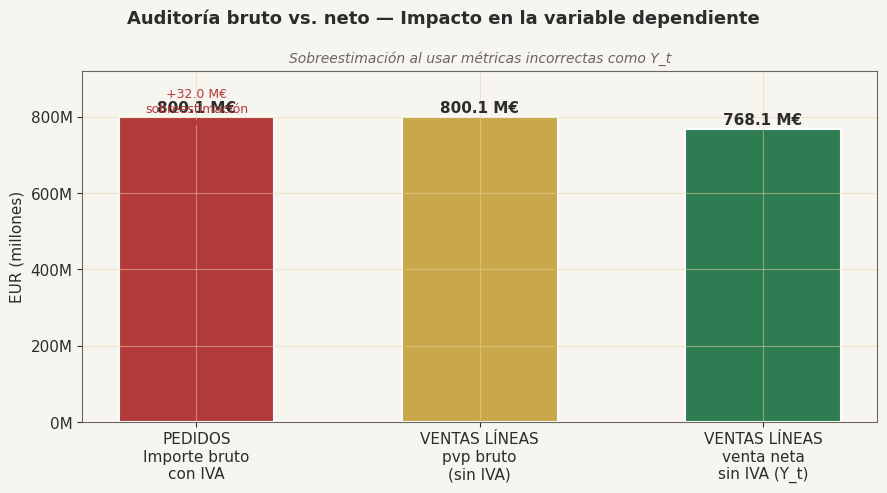

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Auditoría bruto vs. neto — Impacto en la variable dependiente',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

conceptos = [
    'PEDIDOS\nImporte bruto\ncon IVA',
    'VENTAS LÍNEAS\npvp bruto\n(sin IVA)',
    'VENTAS LÍNEAS\nventa neta\nsin IVA (Y_t)',
]
valores = [total_bruto_pedidos / 1e6, total_bruto_lineas / 1e6, total_neto_lineas / 1e6]
colores = [KM['negative'], KM['neutral'], KM['positive']]

bars = ax.bar(conceptos, valores, color=colores, width=0.55, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{val:.1f} M€', ha='center', va='bottom', fontweight='bold',
            fontsize=11, color=KM['charcoal'])

ax.set_ylabel('EUR (millones)', color=KM['charcoal'])
ax.set_title('Sobreestimación al usar métricas incorrectas como Y_t',
             fontsize=10, color=KM['warm_gray'], style='italic')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.set_ylim(0, max(valores) * 1.15)

# Anotación flecha de exceso
exceso = (total_bruto_pedidos - total_neto_lineas) / 1e6
ax.annotate(
    f'+{exceso:.1f} M€\nsobreestimación',
    xy=(0, total_neto_lineas / 1e6), xytext=(0, total_bruto_pedidos / 1e6 + 10),
    ha='center', fontsize=9, color=KM['negative'],
    arrowprops=dict(arrowstyle='->', color=KM['negative'], lw=1.5)
)

plt.tight_layout()
save_fig('01b_bruto_vs_neto')
plt.show()

## 8. Verificacion relacion 1:N — PEDIDOS y VENTAS_LINEAS\n\nEn este dataset **cada pedido tiene exactamente 1 linea**, lo que confirma la relacion integridad referencial pero hace que un histograma de lineas/pedido sea trivial. En su lugar, analizamos la **distribucion del ticket (importe por pedido)**, que aporta informacion de negocio relevante para interpretar los coeficientes del modelo.

In [16]:
# Verificar que cada id_pedido en ventas_lineas existe en pedidos (FK integrity)
pedidos_en_ventas = df_ventas['id_pedido'].nunique()
pedidos_totales   = df_pedidos['id_pedido'].nunique()
lineas_por_pedido = df_ventas.groupby('id_pedido')['id_linea'].count()

print('VERIFICACIÓN RELACIÓN 1:N — PEDIDOS ↔ VENTAS_LINEAS')
print('=' * 55)
print(f'  Pedidos únicos en PEDIDOS:        {pedidos_totales:>10,}')
print(f'  Pedidos únicos en VENTAS_LINEAS:  {pedidos_en_ventas:>10,}')
print(f'  Líneas totales en VENTAS_LINEAS:  {len(df_ventas):>10,}')
print()
print(f'  Líneas por pedido:')
print(f'    Mín:    {lineas_por_pedido.min()}')
print(f'    Media:  {lineas_por_pedido.mean():.2f}')
print(f'    Mediana:{lineas_por_pedido.median():.0f}')
print(f'    Máx:    {lineas_por_pedido.max()}')
print()
print(f'  Distribución (percentiles 75, 90, 99):')
for p in [75, 90, 99]:
    print(f'    P{p}: {lineas_por_pedido.quantile(p/100):.0f} líneas/pedido')

VERIFICACIÓN RELACIÓN 1:N — PEDIDOS ↔ VENTAS_LINEAS
  Pedidos únicos en PEDIDOS:         8,000,000
  Pedidos únicos en VENTAS_LINEAS:   8,000,000
  Líneas totales en VENTAS_LINEAS:   8,000,000

  Líneas por pedido:
    Mín:    1
    Media:  1.00
    Mediana:1
    Máx:    1

  Distribución (percentiles 75, 90, 99):
    P75: 1 líneas/pedido
    P90: 1 líneas/pedido
    P99: 1 líneas/pedido


  Guardado: img\01c_distribucion_ticket.png


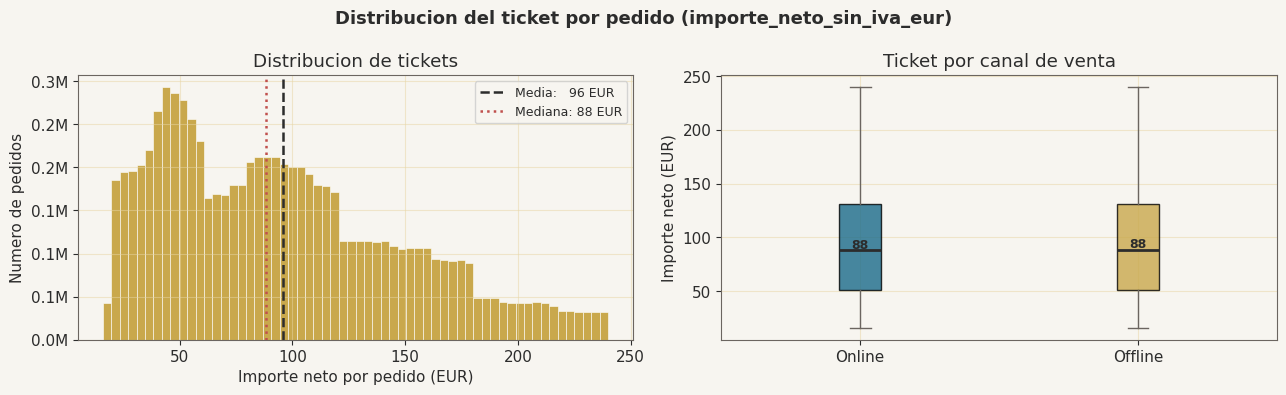

Ticket medio:    96.01 EUR
Ticket mediana:  88.15 EUR
Ticket std:      53.12 EUR
Rango:           16 - 240 EUR


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribucion del ticket por pedido (importe_neto_sin_iva_eur)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

tickets = df_pedidos['importe_neto_sin_iva_eur']

# Histograma
ax = axes[0]
ax.hist(tickets, bins=60, color=KM['gold'], edgecolor='white', linewidth=0.4)
ax.axvline(tickets.mean(),   color=KM['charcoal'], lw=1.8, ls='--', label=f'Media:   {tickets.mean():.0f} EUR')
ax.axvline(tickets.median(), color=KM['radio'],    lw=1.8, ls=':',  label=f'Mediana: {tickets.median():.0f} EUR')
ax.set_xlabel('Importe neto por pedido (EUR)')
ax.set_ylabel('Numero de pedidos')
ax.set_title('Distribucion de tickets')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
ax.legend(fontsize=9)

# Boxplot por canal de venta
ax2 = axes[1]
# canal_venta puede estar en pedidos o en ventas_lineas segun el dataset
if 'canal_venta' in df_pedidos.columns:
    df_ticket_canal = df_pedidos
else:
    canal_map = df_ventas[['id_pedido','canal_venta']].drop_duplicates('id_pedido')
    df_ticket_canal = df_pedidos.merge(canal_map, on='id_pedido', how='left')

canales_venta = df_ticket_canal['canal_venta'].dropna().unique()
datos_canal = [df_ticket_canal[df_ticket_canal['canal_venta']==c]['importe_neto_sin_iva_eur'].values
               for c in canales_venta]
canal_colors_list = {'Online': KM['paid_search'], 'Tienda': KM['radio'], 'ClickCollect': KM['display']}
bp = ax2.boxplot(datos_canal, patch_artist=True,
                 medianprops=dict(color=KM['charcoal'], lw=2),
                 whiskerprops=dict(color=KM['warm_gray']),
                 capprops=dict(color=KM['warm_gray']),
                 flierprops=dict(marker='o', alpha=0.2, ms=2, color=KM['warm_gray']))
for patch, c in zip(bp['boxes'], canales_venta):
    patch.set_facecolor(canal_colors_list.get(c, KM['gold']))
    patch.set_alpha(0.8)
ax2.set_xticklabels(canales_venta)
ax2.set_ylabel('Importe neto (EUR)')
ax2.set_title('Ticket por canal de venta')
for i, datos in enumerate(datos_canal):
    ax2.text(i+1, np.median(datos) + 2, f'{np.median(datos):.0f}',
             ha='center', fontsize=9, color=KM['charcoal'], fontweight='bold')

plt.tight_layout()
save_fig('01c_distribucion_ticket')
plt.show()

print(f'Ticket medio:    {tickets.mean():.2f} EUR')
print(f'Ticket mediana:  {tickets.median():.2f} EUR')
print(f'Ticket std:      {tickets.std():.2f} EUR')
print(f'Rango:           {tickets.min():.0f} - {tickets.max():.0f} EUR')

## 9. Visualizaciones de la señal de ventas

  Guardado: img\01d_serie_ventas_semanal.png


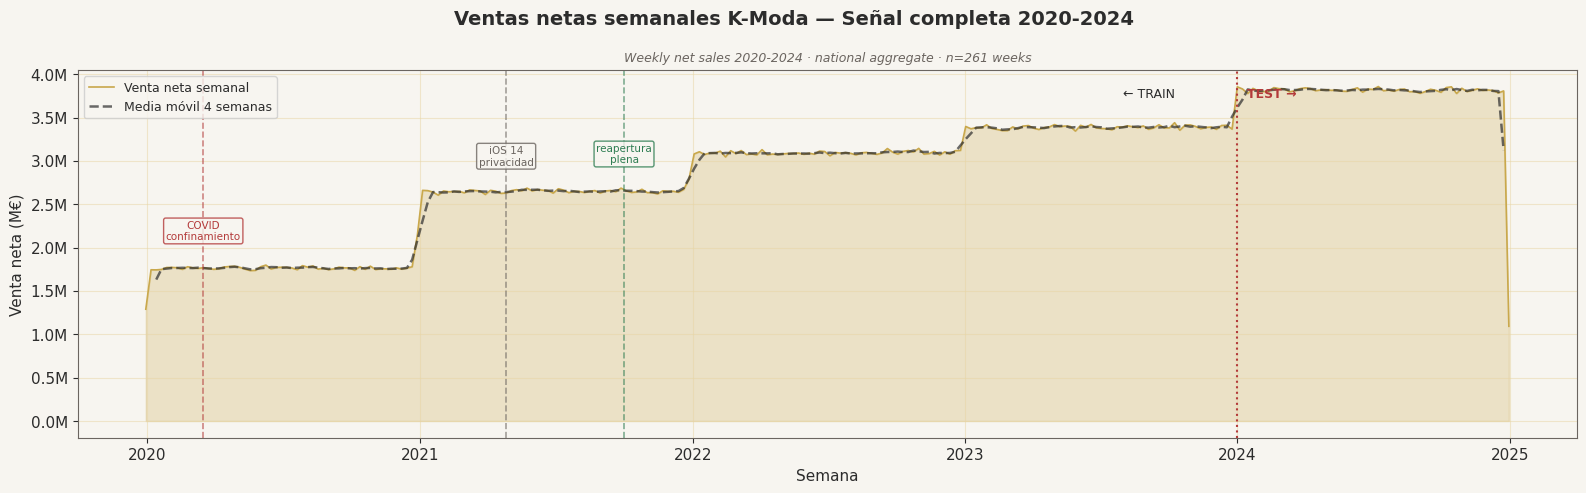

In [18]:
# Serie temporal semanal con eventos clave marcados
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Ventas netas semanales K-Moda — Señal completa 2020-2024',
             fontsize=14, fontweight='bold', color=KM['charcoal'])

ax.fill_between(df_ventas_clean['semana_inicio'],
                df_ventas_clean['venta_neta_sin_iva_eur'] / 1e6,
                alpha=0.25, color=KM['gold'])
ax.plot(df_ventas_clean['semana_inicio'],
        df_ventas_clean['venta_neta_sin_iva_eur'] / 1e6,
        color=KM['gold'], linewidth=1.2, label='Venta neta semanal')

# Media móvil 4 semanas
rolling = df_ventas_clean['venta_neta_sin_iva_eur'].rolling(4, center=True).mean() / 1e6
ax.plot(df_ventas_clean['semana_inicio'], rolling,
        color=KM['charcoal'], linewidth=1.8, linestyle='--', label='Media móvil 4 semanas', alpha=0.7)

# Separador train/test
ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'], linewidth=1.5, linestyle=':')
ax.text(pd.Timestamp('2024-01-14'), ax.get_ylim()[1] * 0.92, 'TEST →', 
        color=KM['negative'], fontsize=9, fontweight='bold')
ax.text(pd.Timestamp('2023-08-01'), ax.get_ylim()[1] * 0.92, '← TRAIN',
        color=KM['charcoal'], fontsize=9)

# Eventos clave
eventos = [
    ('2020-03-16', 'COVID\nconfinamiento', KM['negative']),
    ('2021-04-26', 'iOS 14\nprivacidad', KM['warm_gray']),
    ('2021-10-01', 'reapertura\nplena', KM['positive']),
]
for fecha, label, color in eventos:
    ax.axvline(pd.Timestamp(fecha), color=color, linewidth=1.2, linestyle='--', alpha=0.6)
    y_pos = df_ventas_clean.loc[
        df_ventas_clean['semana_inicio'] >= fecha, 'venta_neta_sin_iva_eur'
    ].iloc[0] / 1e6 + 0.3
    ax.text(pd.Timestamp(fecha), y_pos, label,
            fontsize=7.5, color=color, ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=KM['off_white'],
                      edgecolor=color, alpha=0.8))

ax.set_ylabel('Venta neta (M€)', color=KM['charcoal'])
ax.set_xlabel('Semana', color=KM['charcoal'])
ax.set_title('Weekly net sales 2020-2024 · national aggregate · n=261 weeks',
             fontsize=9, color=KM['warm_gray'], style='italic')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
save_fig('01d_serie_ventas_semanal')
plt.show()

In [19]:
# Estadísticas descriptivas por año
df_ventas_clean['anio'] = df_ventas_clean['semana_inicio'].dt.year
stats_anio = (
    df_ventas_clean
    .groupby('anio')['venta_neta_sin_iva_eur']
    .agg(['sum', 'mean', 'std', lambda x: x.std() / x.mean()])
    .rename(columns={'sum': 'Total (EUR)', 'mean': 'Media semanal', 'std': 'Desv. Típica', '<lambda_0>': 'CV'})
)
stats_anio['Total (M€)']       = stats_anio['Total (EUR)'] / 1e6
stats_anio['Media semanal (€)'] = stats_anio['Media semanal'].apply(lambda x: f'{x:,.0f}')
stats_anio['Desv. Típica (€)']  = stats_anio['Desv. Típica'].apply(lambda x: f'{x:,.0f}')
stats_anio['CV (%)']            = (stats_anio['CV'] * 100).round(1)

print('ESTADÍSTICAS DESCRIPTIVAS POR AÑO')
print('(Relevante para análisis de cambio de distribución Train vs Test en Fase 4)')
print()
display_cols = ['Total (M€)', 'Media semanal (€)', 'Desv. Típica (€)', 'CV (%)']
print(stats_anio[display_cols].round(2).to_string())

ESTADÍSTICAS DESCRIPTIVAS POR AÑO
(Relevante para análisis de cambio de distribución Train vs Test en Fase 4)

      Total (M€) Media semanal (€) Desv. Típica (€)  CV (%)
anio                                                       
2019        1.29         1,289,867              nan     NaN
2020       92.11         1,771,338           55,035     3.1
2021      137.97         2,653,224           25,803     1.0
2022      160.87         3,093,563           20,543     0.7
2023      176.21         3,388,641           21,134     0.6
2024      199.65         3,766,953          374,888    10.0


  Guardado: img\01e_inversion_por_canal.png


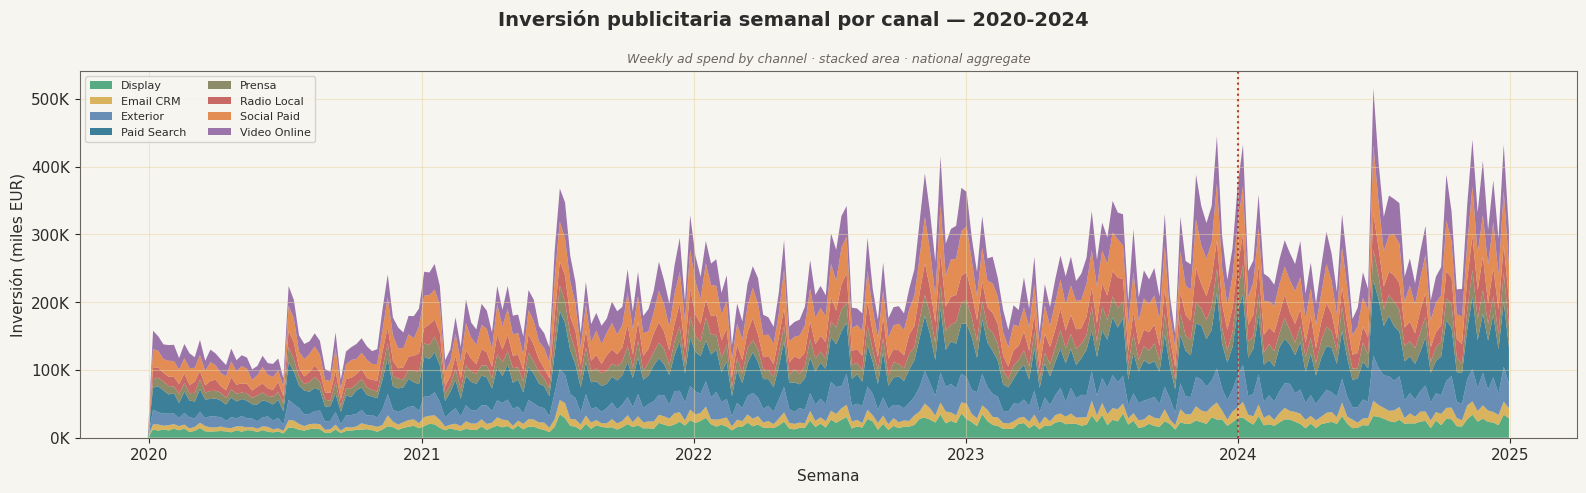

In [20]:
# Inversión por canal a lo largo del tiempo
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Inversión publicitaria semanal por canal — 2020-2024',
             fontsize=14, fontweight='bold', color=KM['charcoal'])

inv_plot = df_inv_clean.set_index('semana_inicio')[canales] / 1e3  # en miles EUR

# Stacked area
colors_stack = [CANAL_COLOR[c] for c in canales]
ax.stackplot(inv_plot.index, [inv_plot[c] for c in canales],
             labels=canales, colors=colors_stack, alpha=0.85)

ax.set_ylabel('Inversión (miles EUR)', color=KM['charcoal'])
ax.set_xlabel('Semana')
ax.set_title('Weekly ad spend by channel · stacked area · national aggregate',
             fontsize=9, color=KM['warm_gray'], style='italic')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.85)
ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'], linewidth=1.5, linestyle=':', label='Train/Test')

plt.tight_layout()
save_fig('01e_inversion_por_canal')
plt.show()

  Guardado: img\01f_mix_inversion.png


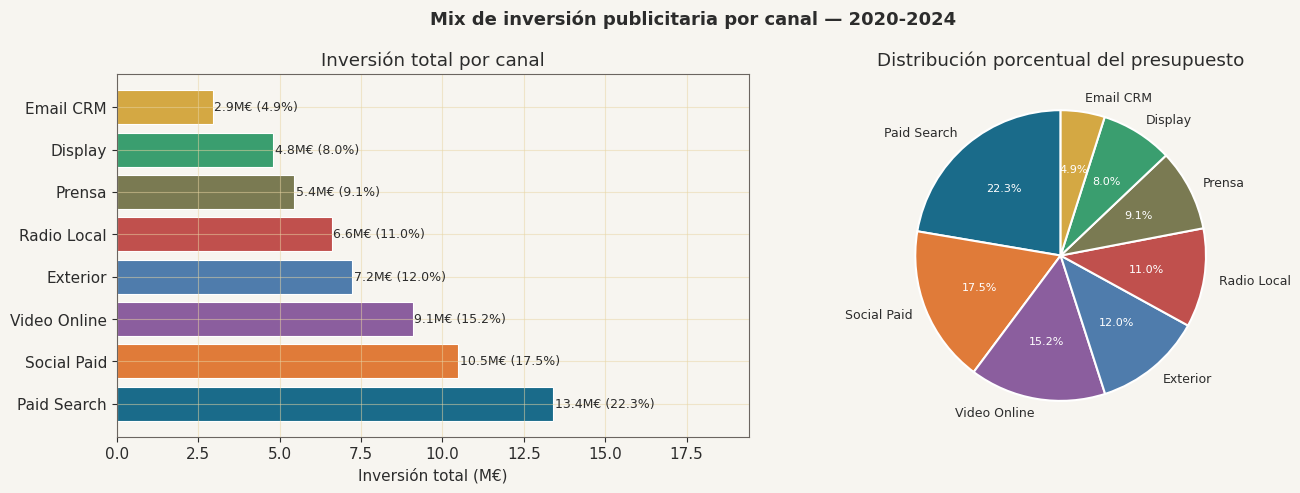

In [21]:
# Mix de inversión por canal (% del total)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mix de inversión publicitaria por canal — 2020-2024',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

inv_total_canal = df_inv_clean[canales].sum().sort_values(ascending=False)
pct_canal = inv_total_canal / inv_total_canal.sum() * 100

# Barras horizontales
ax = axes[0]
ax.barh(inv_total_canal.index, inv_total_canal.values / 1e6,
        color=[CANAL_COLOR[c] for c in inv_total_canal.index],
        edgecolor='white', linewidth=0.8)
for i, (canal, val) in enumerate(inv_total_canal.items()):
    ax.text(val / 1e6 + 0.05, i, f'{val/1e6:.1f}M€ ({pct_canal[canal]:.1f}%)',
            va='center', fontsize=9, color=KM['charcoal'])
ax.set_xlabel('Inversión total (M€)')
ax.set_title('Inversión total por canal')
ax.set_xlim(0, inv_total_canal.max() / 1e6 * 1.45)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    inv_total_canal.values,
    labels=inv_total_canal.index,
    colors=[CANAL_COLOR[c] for c in inv_total_canal.index],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 9, 'color': KM['charcoal']},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(8)
ax2.set_title('Distribución porcentual del presupuesto')

plt.tight_layout()
save_fig('01f_mix_inversion')
plt.show()

## 10. Exportación de artefactos

In [22]:
# ── df_ventas_clean ──────────────────────────────────────────────────────────
# Columnas finales: semana_inicio + flags del calendario + métricas de ventas
ventas_out_cols = ['semana_inicio', 'anio', 'mes', 'anio_iso', 'semana_iso',
                   'venta_neta_sin_iva_eur', 'n_lineas', 'n_pedidos', 'ticket_medio',
                   'payday_flag', 'rebajas_flag', 'black_friday_flag',
                   'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag',
                   'festivo_local_flag', 'incidencia_ecommerce_flag',
                   'temperatura_media_c', 'lluvia_indice', 'turismo_indice']

df_ventas_clean_out = df_ventas_clean[ventas_out_cols].copy()

path_ventas = DATA_OUT / 'df_ventas_clean.parquet'
df_ventas_clean_out.to_parquet(path_ventas, index=False)
print(f'✓ df_ventas_clean.parquet — shape: {df_ventas_clean_out.shape} — {path_ventas.stat().st_size/1024:.1f} KB')

# ── df_inversion_clean ───────────────────────────────────────────────────────
inv_out_cols = ['semana_inicio', 'anio', 'anio_iso', 'semana_iso'] + canales
df_inv_clean_out = df_inv_clean[inv_out_cols].copy()

path_inv = DATA_OUT / 'df_inversion_clean.parquet'
df_inv_clean_out.to_parquet(path_inv, index=False)
print(f'✓ df_inversion_clean.parquet — shape: {df_inv_clean_out.shape} — {path_inv.stat().st_size/1024:.1f} KB')

print()
print('RESUMEN DE ARTEFACTOS EXPORTADOS')
print('-' * 55)
print(f'  df_ventas_clean:  {len(df_ventas_clean_out)} semanas · {df_ventas_clean_out.columns.tolist()}')
print(f'  df_inv_clean:     {len(df_inv_clean_out)} semanas · {len(canales)} canales')
print()
print('VERIFICACIONES FINALES')
print(f'  Total ventas netas:    {df_ventas_clean_out.venta_neta_sin_iva_eur.sum():,.0f} EUR')
print(f'  Total inversión:       {df_inv_clean_out[canales].sum().sum():,.0f} EUR')
print(f'  Semanas train (2020-2023): {(df_ventas_clean_out.anio <= 2023).sum()}')
print(f'  Semanas test  (2024):      {(df_ventas_clean_out.anio == 2024).sum()}')

✓ df_ventas_clean.parquet — shape: (262, 20) — 28.6 KB
✓ df_inversion_clean.parquet — shape: (262, 12) — 25.1 KB

RESUMEN DE ARTEFACTOS EXPORTADOS
-------------------------------------------------------
  df_ventas_clean:  262 semanas · ['semana_inicio', 'anio', 'mes', 'anio_iso', 'semana_iso', 'venta_neta_sin_iva_eur', 'n_lineas', 'n_pedidos', 'ticket_medio', 'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag', 'incidencia_ecommerce_flag', 'temperatura_media_c', 'lluvia_indice', 'turismo_indice']
  df_inv_clean:     262 semanas · 8 canales

VERIFICACIONES FINALES
  Total ventas netas:    768,090,254 EUR
  Total inversión:       60,000,000 EUR
  Semanas train (2020-2023): 209
  Semanas test  (2024):      53


## 11. Resumen de hallazgos de la Fase 1

| Hallazgo | Detalle | Impacto en el modelo |
|---|---|---|
| **Mismatch de ciudades** | ventas: 5 ciudades · inversión: 10 ciudades | Modelo obligatoriamente nacional |
| **Consistencia neto** | PEDIDOS.neto ≈ VENTAS_LINEAS.neto (< 1 EUR diferencia) | Alta integridad referencial |
| **Sobreestimación bruto** | PEDIDOS bruto / LINEAS neto ≈ 1.042x | Usar siempre venta_neta_sin_iva_eur como Y_t |
| **ISO week boundary** | Semana 2024-12-30 etiquetada anio=2025 | Usar semana_inicio como clave, no campo anio |
| **Semanas sin ventas** | Verificado con LEFT JOIN desde CALENDARIO | Ninguna semana tiene NaN en Y_t |
| **Rango completo** | 2020-01-01 → 2024-12-31 en todas las tablas | Split train/test viable sin truncamiento |

**Siguiente fase:** `02_eda.ipynb` — Exploración en profundidad de la señal de ventas, estacionalidad y correlaciones preliminares con la inversión publicitaria.